# RL Data Analysis — Doubles (collect_rl_data_doubles.py output)

This notebook analyzes the CSVs produced by `collect_rl_data_doubles.py`:
- **rl_turns_\*.csv**: per-turn, per-slot state, action, damage/type info, and outcome.
- **rl_battles_\*.csv**: per-battle summary (teams, winner, turns).

Set the file paths below, then run all cells.

In [4]:
import os
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

In [5]:
# --- CONFIGURATION ---
# Paths relative to this notebook (2_vs_2) or absolute.

turns_csv = "../../../data/rl_turns_5d5439.csv"   # replace with your rl_turns_<runid>.csv
battles_csv = "../../../data/rl_battles_5d5439.csv"  # replace with your rl_battles_<runid>.csv
output_dir = "../../../data/rl_analysis_5d5439.csv"  # where to save plots

Path(output_dir).mkdir(parents=True, exist_ok=True)

In [6]:
# Load data
df_turns = pd.read_csv(turns_csv)
df_battles = pd.read_csv(battles_csv)

print("Turns shape:", df_turns.shape)
print("Battles shape:", df_battles.shape)
print("\nTurns columns:", list(df_turns.columns))
print("\nBattles columns:", list(df_battles.columns))

Turns shape: (1156678, 28)
Battles shape: (10000, 5)

Turns columns: ['battle_id', 'heuristic', 'turn', 'remaining_us', 'remaining_opp', 'weather', 'terrain', 'our_species_0', 'our_types_0', 'our_hp_frac_0', 'our_species_1', 'our_types_1', 'our_hp_frac_1', 'opp_species_0', 'opp_types_0', 'opp_hp_frac_0', 'opp_species_1', 'opp_types_1', 'opp_hp_frac_1', 'slot', 'action_type', 'move_id', 'move_target', 'switch_species', 'estimated_damage', 'type_multiplier', 'battle_winner', 'total_turns']

Battles columns: ['battle_id', 'winner', 'turns', 'team_us', 'team_opp']


## 1. Battles overview

Win distribution and turn statistics.

In [7]:
print("Winner distribution:")
print(df_battles["winner"].value_counts())
print("\nTurn stats:")
print(df_battles["turns"].describe())

Winner distribution:
winner
opp    5032
us     4968
Name: count, dtype: int64

Turn stats:
count    10000.000000
mean        17.544300
std          6.107747
min          5.000000
25%         14.000000
50%         17.000000
75%         20.000000
max        109.000000
Name: turns, dtype: float64


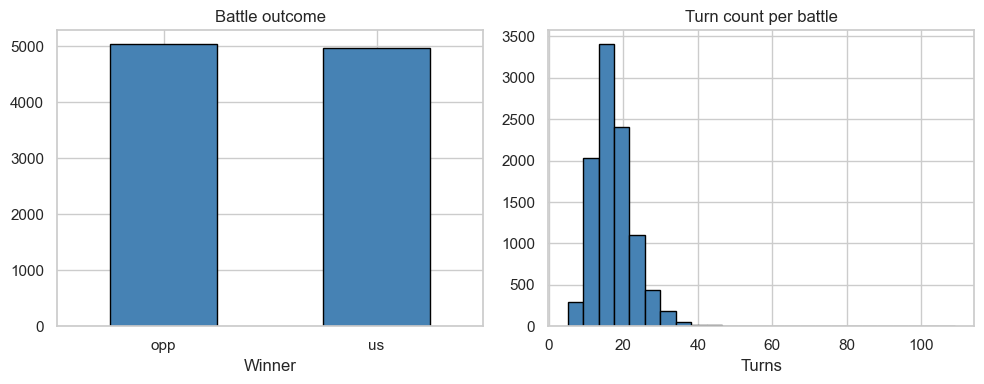

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df_battles["winner"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Battle outcome")
axes[0].set_xlabel("Winner")
axes[0].tick_params(axis="x", rotation=0)

df_battles["turns"].hist(bins=25, ax=axes[1], color="steelblue", edgecolor="black")
axes[1].set_title("Turn count per battle")
axes[1].set_xlabel("Turns")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "rl_battles_outcome_and_turns.png"), dpi=150, bbox_inches="tight")
plt.show()

## 2. Turns — action types and moves

How often each heuristic uses moves vs switches, and which moves are most used.

In [9]:
print("Action type by heuristic:")
print(pd.crosstab(df_turns["heuristic"], df_turns["action_type"], normalize="index").round(3))
print("\nAction type counts:")
print(df_turns["action_type"].value_counts())

Action type by heuristic:
action_type   move  switch
heuristic                 
v1           0.225   0.775
v2           0.243   0.757

Action type counts:
action_type
switch    886680
move      269998
Name: count, dtype: int64


In [10]:
moves = df_turns[df_turns["action_type"] == "move"].copy()
top_moves = moves["move_id"].value_counts().head(20)
print("Top 20 moves (all heuristics):")
print(top_moves)

Top 20 moves (all heuristics):
move_id
protect           14892
knockoff          12333
closecombat        7139
thunderbolt        6523
highhorsepower     6441
psychic            6051
bodypress          5714
thunderwave        5599
earthpower         5054
shadowball         4204
fakeout            3997
encore             3955
dracometeor        3788
gunkshot           3731
bravebird          3633
hydropump          3552
tailwind           3010
hurricane          3008
moonblast          3000
scald              2970
Name: count, dtype: int64


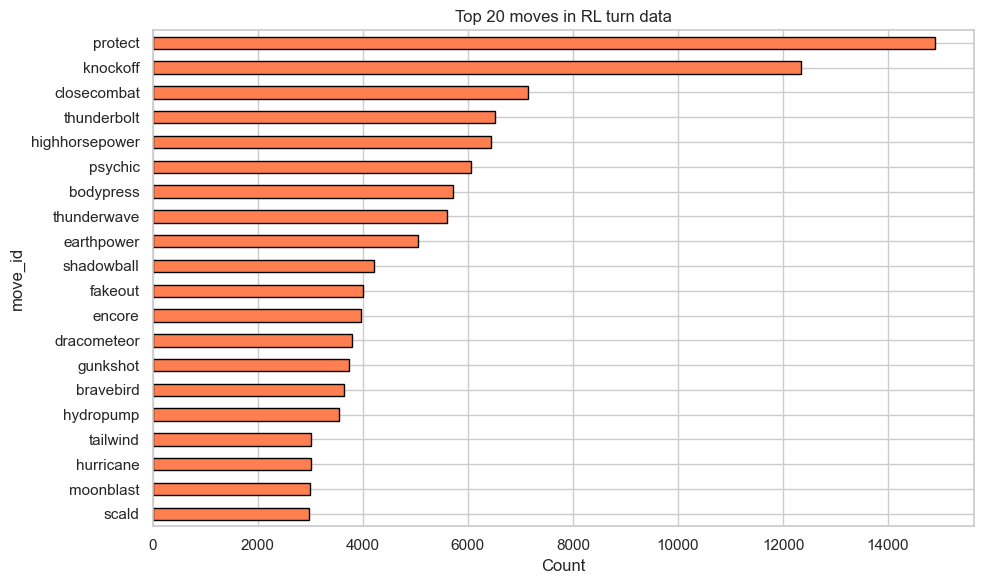

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
top_moves.plot(kind="barh", ax=ax, color="coral", edgecolor="black")
ax.set_title("Top 20 moves in RL turn data")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "rl_top_moves.png"), dpi=150, bbox_inches="tight")
plt.show()

In [12]:
top_by_heuristic = (
    moves.groupby("heuristic")["move_id"]
    .value_counts()
    .reset_index(name="count")
)
print("Top 10 moves per heuristic:")
for h in moves["heuristic"].unique():
    sub = top_by_heuristic[top_by_heuristic["heuristic"] == h].head(10)
    print(f"\n{h}:", sub["move_id"].tolist())

Top 10 moves per heuristic:

v1: ['protect', 'knockoff', 'closecombat', 'thunderbolt', 'highhorsepower', 'psychic', 'bodypress', 'thunderwave', 'earthpower', 'shadowball']

v2: ['protect', 'knockoff', 'closecombat', 'thunderbolt', 'highhorsepower', 'psychic', 'bodypress', 'thunderwave', 'earthpower', 'shadowball']


## 3. Damage and type effectiveness

Estimated damage and type multiplier (e.g. 2.0 = super effective). Useful to see what the RL can learn from the data.

In [13]:
dmg = moves["estimated_damage"].dropna()
mult = moves["type_multiplier"].dropna()
print("Estimated damage (move rows only):")
print(dmg.describe())
print("\nType multiplier (move rows only):")
print(mult.describe())
print("\nType multiplier value counts (rounded):")
print(mult.round(2).value_counts().head(15))

Estimated damage (move rows only):
count    256032.000000
mean        122.913983
std         145.376403
min           0.000000
25%           0.000000
50%          92.785000
75%         179.360000
max        4918.000000
Name: estimated_damage, dtype: float64

Type multiplier (move rows only):
count    256032.000000
mean          0.996161
std           0.567932
min           0.000000
25%           0.500000
50%           1.000000
75%           1.000000
max           4.000000
Name: type_multiplier, dtype: float64

Type multiplier value counts (rounded):
type_multiplier
1.00    148059
0.50     54269
2.00     34909
0.00     11525
0.25      5078
4.00      2192
Name: count, dtype: int64


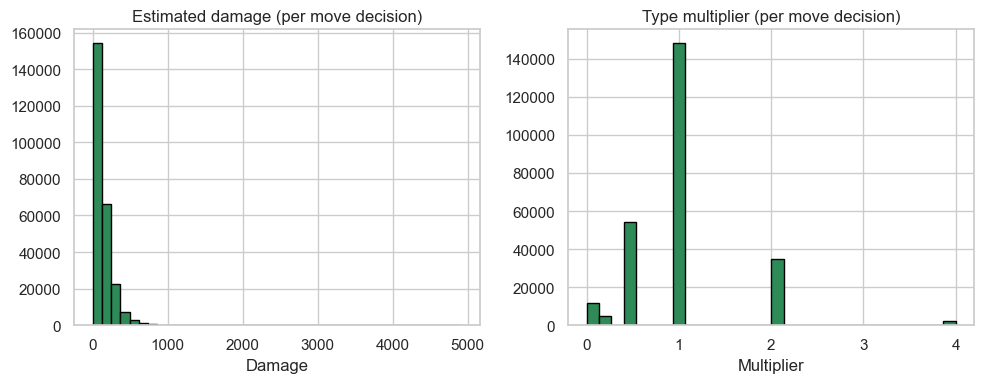

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

dmg.hist(bins=40, ax=axes[0], color="seagreen", edgecolor="black")
axes[0].set_title("Estimated damage (per move decision)")
axes[0].set_xlabel("Damage")

mult.hist(bins=30, ax=axes[1], color="seagreen", edgecolor="black")
axes[1].set_title("Type multiplier (per move decision)")
axes[1].set_xlabel("Multiplier")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "rl_damage_and_type_multiplier.png"), dpi=150, bbox_inches="tight")
plt.show()

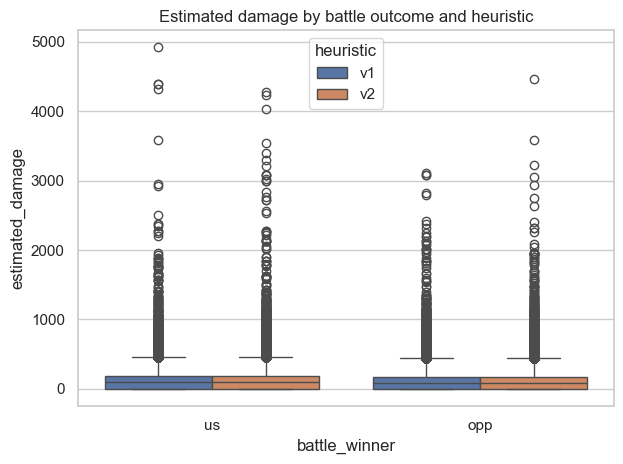

In [15]:
# Damage vs battle outcome (when we were "us")
moves_with_outcome = moves[moves["battle_winner"].notna()].copy()
if len(moves_with_outcome) > 0:
    sns.boxplot(data=moves_with_outcome, x="battle_winner", y="estimated_damage", hue="heuristic")
    plt.title("Estimated damage by battle outcome and heuristic")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "rl_damage_by_outcome.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No rows with battle_winner for this plot.")

## 4. State features (for RL observation space)

Distributions of turn, remaining mons, HP fractions, weather/terrain.

In [16]:
state_cols = ["turn", "remaining_us", "remaining_opp", "our_hp_frac_0", "our_hp_frac_1", "opp_hp_frac_0", "opp_hp_frac_1"]
available_state = [c for c in state_cols if c in df_turns.columns]
print("State summary:")
print(df_turns[available_state].describe())
if "weather" in df_turns.columns:
    print("\nWeather value counts:")
    print(df_turns["weather"].value_counts().head(10))
if "terrain" in df_turns.columns:
    print("\nTerrain value counts:")
    print(df_turns["terrain"].value_counts().head(10))

State summary:
               turn  remaining_us  remaining_opp  our_hp_frac_0  \
count  1.156678e+06  1.156678e+06   1.156678e+06   1.156678e+06   
mean   1.241665e+01  2.032663e+00   3.425953e+00   2.051236e-01   
std    5.569415e+00  1.739462e+00   1.545916e+00   3.536811e-01   
min    1.000000e+00  0.000000e+00   1.000000e+00   0.000000e+00   
25%    9.000000e+00  1.000000e+00   2.000000e+00   0.000000e+00   
50%    1.200000e+01  1.000000e+00   3.000000e+00   0.000000e+00   
75%    1.500000e+01  3.000000e+00   5.000000e+00   3.273381e-01   
max    1.090000e+02  6.000000e+00   6.000000e+00   1.000000e+00   

       our_hp_frac_1  opp_hp_frac_0  opp_hp_frac_1  
count   1.156678e+06   1.156678e+06   1.156678e+06  
mean    2.019543e-01   5.525968e-01   5.468617e-01  
std     3.524190e-01   3.490172e-01   3.448140e-01  
min     0.000000e+00   0.000000e+00   0.000000e+00  
25%     0.000000e+00   2.200000e-01   2.600000e-01  
50%     0.000000e+00   5.900000e-01   5.700000e-01  
75%     3.

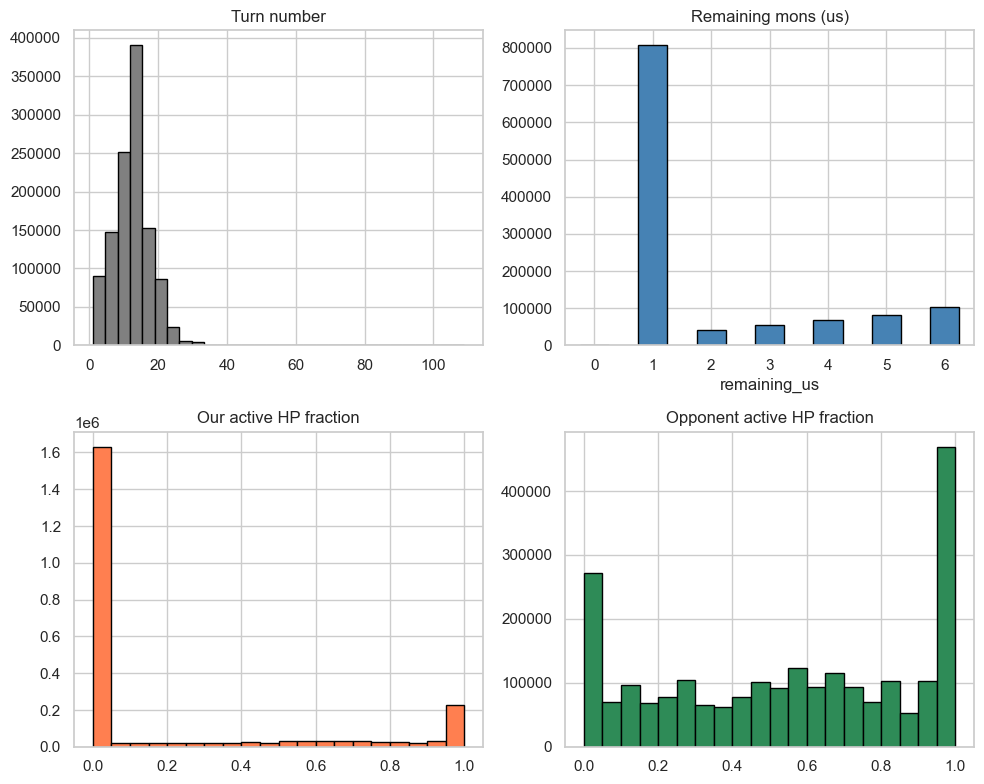

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

df_turns["turn"].hist(bins=min(30, df_turns["turn"].nunique()), ax=axes[0, 0], color="gray", edgecolor="black")
axes[0, 0].set_title("Turn number")

df_turns["remaining_us"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 1], color="steelblue", edgecolor="black")
axes[0, 1].set_title("Remaining mons (us)")
axes[0, 1].tick_params(axis="x", rotation=0)

df_turns[["our_hp_frac_0", "our_hp_frac_1"]].stack().hist(bins=20, ax=axes[1, 0], color="coral", edgecolor="black")
axes[1, 0].set_title("Our active HP fraction")

df_turns[["opp_hp_frac_0", "opp_hp_frac_1"]].stack().hist(bins=20, ax=axes[1, 1], color="seagreen", edgecolor="black")
axes[1, 1].set_title("Opponent active HP fraction")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "rl_state_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. Heuristic comparison (v1 vs v2)

When the row is from heuristic v1, "us" means v1 won that battle; when from v2, "us" means v2 won. So we can compare win rate and behavior.

In [18]:
# One row per battle with winner; we need winner from perspective of the heuristic that made the decisions.
# In our CSV, each turn row has heuristic (v1 or v2) and battle_winner (us/opp/draw).
# So for rows where heuristic==v1, battle_winner==us means v1 won that battle.
per_battle = df_turns.drop_duplicates(subset=["battle_id", "heuristic"], keep="first")[
    ["battle_id", "heuristic", "battle_winner", "total_turns"]
].dropna(subset=["battle_winner"])

win_rates = per_battle.groupby("heuristic")["battle_winner"].apply(
    lambda s: (s == "us").mean() * 100
)
print("Win rate (% us) by heuristic (from turn-level data):")
print(win_rates)

turn_means = per_battle.groupby("heuristic")["total_turns"].mean()
print("\nMean total turns by heuristic:")
print(turn_means)

Win rate (% us) by heuristic (from turn-level data):
heuristic
v1    49.08
v2    50.28
Name: battle_winner, dtype: float64

Mean total turns by heuristic:
heuristic
v1    17.5020
v2    17.5866
Name: total_turns, dtype: float64


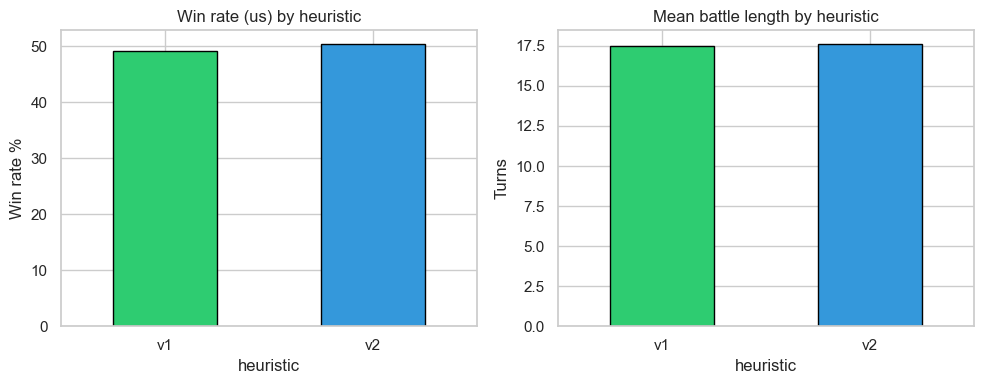

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

win_rates.plot(kind="bar", ax=axes[0], color=["#2ecc71", "#3498db"], edgecolor="black")
axes[0].set_title("Win rate (us) by heuristic")
axes[0].set_ylabel("Win rate %")
axes[0].tick_params(axis="x", rotation=0)

turn_means.plot(kind="bar", ax=axes[1], color=["#2ecc71", "#3498db"], edgecolor="black")
axes[1].set_title("Mean battle length by heuristic")
axes[1].set_ylabel("Turns")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "rl_heuristic_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6. Summary table for RL

Quick reference: sample sizes and key stats to feed into training (e.g. state ranges, action space size).

In [20]:
n_battles = df_battles.shape[0]
n_turn_rows = df_turns.shape[0]
n_move_decisions = (df_turns["action_type"] == "move").sum()
n_switch_decisions = (df_turns["action_type"] == "switch").sum()
unique_moves = df_turns.loc[df_turns["action_type"] == "move", "move_id"].nunique()

summary = pd.DataFrame({
    "Metric": [
        "Total battles",
        "Total turn rows (state-action)",
        "Move decisions",
        "Switch decisions",
        "Unique move IDs",
        "Mean estimated damage (moves)",
        "Mean type multiplier (moves)",
    ],
    "Value": [
        n_battles,
        n_turn_rows,
        n_move_decisions,
        n_switch_decisions,
        unique_moves,
        round(moves["estimated_damage"].mean(), 2),
        round(moves["type_multiplier"].mean(), 2),
    ],
})
print("RL data summary")
display(summary)

RL data summary


,Metric,Value
0,Total battles,10000.00
1,Total turn rows (state-action),1156678.00
2,Move decisions,269998.00
3,Switch decisions,886680.00
4,Unique move IDs,361.00
5,Mean estimated damage (moves),122.91
6,Mean type multiplier (moves),1.00
